# Task (e) — Curved tracks in a magnetic field

Task (d) handled straight tracks. Task (e) gives a dataset where a magnetic field
bends the tracks, with 5 to 15 tracks per event. The curvature depends on the
transverse momentum and the charge sign. The job is the same, group each event's
hits by track with the same permutation-invariant evaluation.

My plan is: first explore the data and work out the track model by fitting (it
turns out each track is a circle through the origin with radius of curvature
equal to the momentum) then show that the straight-line angle baseline breaks on
curved tracks, which is the reason a learned method is worth it. Then apply the
exact same transformer from task (d), unchanged in method, using the upgraded
settings (bigger model, layer feature, early stopping).

On inputs: the network only ever sees per-hit features (x, y, and the layer
index). The track parameters theta, pt and charge are used only to build the
training targets and to score results, never as inputs. I recover parameters
afterwards by fitting the grouped hits.

### Setup

In [1]:
import numpy as np, pandas as pd, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score


# ----- simulator.py (incl. curved-track model) -----

COLUMNS = ["event_id", "track_id", "layer", "x", "y", "phi"]


# --- detector geometry -------------------------------------------------------

def detector_radii(n_circles: int = 5, spacing: float = 2.0) -> np.ndarray:
    return spacing * np.arange(1, n_circles + 1)


# --- track generation --------------------------------------------------------

def sample_track_angles(n_tracks: int,
                        rng: np.random.Generator,
                        min_sep: float = 0.0) -> np.ndarray:
    if min_sep <= 0.0:
        return rng.uniform(0.0, 2.0 * np.pi, size=n_tracks)

    phis: list[float] = []
    while len(phis) < n_tracks:
        cand = rng.uniform(0.0, 2.0 * np.pi)
        if all(_angular_gap(cand, p) >= min_sep for p in phis):
            phis.append(cand)
    return np.array(phis)


def _angular_gap(a: float, b: float) -> float:
    d = abs(a - b) % (2.0 * np.pi)
    return min(d, 2.0 * np.pi - d)


def track_hits(phi: float, radii: np.ndarray) -> np.ndarray:
    x = radii * np.cos(phi)
    y = radii * np.sin(phi)
    return np.column_stack([x, y])


# --- events ------------------------------------------------------------------

def simulate_event(event_id: int,
                   n_tracks: int = 3,
                   n_circles: int = 5,
                   spacing: float = 2.0,
                   efficiency: float = 1.0,
                   smear: float = 0.0,
                   min_sep: float = 0.0,
                   rng: np.random.Generator | None = None) -> pd.DataFrame:
    if rng is None:
        rng = np.random.default_rng()

    radii = detector_radii(n_circles, spacing)
    phis = sample_track_angles(n_tracks, rng, min_sep=min_sep)

    rows = []
    for track_id, phi in enumerate(phis):
        hits = track_hits(phi, radii)                 
        keep = rng.random(n_circles) < efficiency
        layers = np.nonzero(keep)[0]
        hits = hits[keep]
        if smear > 0.0 and len(hits):
            sigma = smear * radii[keep]               # (m,)
            noise = rng.normal(0.0, 1.0, hits.shape) * sigma[:, None]
            hits = hits + noise

        for layer, (x, y) in zip(layers, hits):
            rows.append((event_id, track_id, layer, x, y, phi))

    return pd.DataFrame(rows, columns=COLUMNS)


def simulate_events(n_events: int, seed: int | None = None, **kwargs) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = [simulate_event(i, rng=rng, **kwargs) for i in range(n_events)]
    return pd.concat(frames, ignore_index=True)




def curved_track_hits(theta: float, pt: float, charge: int,
                      radii: np.ndarray, n_samples: int = 20000) -> tuple:
    Rc = pt
    center_ang = theta - charge * np.pi / 2.0
    C = np.array([Rc * np.cos(center_ang), Rc * np.sin(center_ang)])
    a0 = np.arctan2(-C[1], -C[0])                      # origin's angle on circle
    tang = np.array([-np.sin(a0), np.cos(a0)])         # tangent at the origin
    s_dir = np.sign(np.dot(tang, [np.cos(theta), np.sin(theta)])) or 1.0
    s = np.linspace(0.0, s_dir * 2.0 * np.pi, n_samples)
    P = C[:, None] + Rc * np.vstack([np.cos(a0 + s), np.sin(a0 + s)])
    r = np.hypot(P[0], P[1])
    hits, layers = [], []
    for i, R in enumerate(radii):
        cross = np.where(np.diff(np.sign(r - R)))[0]
        if len(cross):
            k = cross[0]
            hits.append((P[0, k], P[1, k])); layers.append(i)
    return (np.array(hits) if hits else np.empty((0, 2))), layers


def simulate_curved_event(event_id: int, n_tracks: int, n_circles: int = 5,
                          spacing: float = 2.0, efficiency: float = 0.95,
                          smear: float = 0.001, pt_range=(6.0, 24.0),
                          rng: np.random.Generator | None = None) -> pd.DataFrame:
    if rng is None:
        rng = np.random.default_rng()
    radii = detector_radii(n_circles, spacing)
    rows = []
    for tid in range(n_tracks):
        theta = rng.uniform(0, 2 * np.pi)
        pt = rng.uniform(*pt_range)
        charge = int(rng.choice([-1, 1]))
        hits, layers = curved_track_hits(theta, pt, charge, radii)
        for (x, y), layer in zip(hits, layers):
            if rng.random() >= efficiency:            # 95% efficiency
                continue
            if smear > 0:
                sig = smear * radii[layer]
                x += rng.normal(0, sig); y += rng.normal(0, sig)
            rows.append((event_id, tid, layer, x, y, theta, pt, charge))
    return pd.DataFrame(rows, columns=["event_id", "track_id", "layer",
                                       "x", "y", "theta", "pt", "charge"])


def simulate_curved_events(n_events: int, seed: int | None = None,
                           n_tracks_range=(5, 15), **kwargs) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    frames = []
    for i in range(n_events):
        k = rng.integers(n_tracks_range[0], n_tracks_range[1] + 1)
        frames.append(simulate_curved_event(i, int(k), rng=rng, **kwargs))
    return pd.concat(frames, ignore_index=True)


# --- dataset -----------------------------------------------------------------

class EventDataset(Dataset):
    def __init__(self, df: pd.DataFrame, scale: float = 10.0,
                 extra_cols: list[str] | None = None,
                 extra_scale: float = 1.0):
        self.scale = scale
        self.extra_cols = extra_cols or []
        self.extra_scale = extra_scale
        # groupby preserves within-event row order; sort=False keeps event order
        self.events = []
        for _, g in df.groupby("event_id", sort=False):
            feats = [g["x"].to_numpy() / scale, g["y"].to_numpy() / scale]
            feats += [g[c].to_numpy() / extra_scale for c in self.extra_cols]
            x = np.column_stack(feats).astype(np.float32)
            # labels are only used to build the pairwise target -> their
            # numeric values are irrelevant (permutation invariance)
            y = g["track_id"].to_numpy().astype(np.int64)
            self.events.append((torch.from_numpy(x), torch.from_numpy(y)))

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        return self.events[i]


def collate_events(batch):
    n_max = max(x.shape[0] for x, _ in batch)
    B, F = len(batch), batch[0][0].shape[1]
    hits = torch.zeros(B, n_max, F)
    labels = torch.full((B, n_max), -1, dtype=torch.long)
    mask = torch.zeros(B, n_max, dtype=torch.bool)
    for i, (x, y) in enumerate(batch):
        n = x.shape[0]
        hits[i, :n] = x
        labels[i, :n] = y
        mask[i, :n] = True
    return hits, labels, mask


# --- model --------------------------------------------------------------------

class HitSetTransformer(nn.Module):
    def __init__(self, n_features: int = 2, d_model: int = 64, n_heads: int = 4,
                 n_layers: int = 3, d_ff: int = 128, d_embed: int = 32,
                 dropout: float = 0.0):
        super().__init__()
        self.embed = nn.Sequential(
            nn.Linear(n_features, d_model), nn.ReLU(),
            nn.Linear(d_model, d_model),
        )
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers,
                                             enable_nested_tensor=False)
        self.head = nn.Linear(d_model, d_embed)   
        self.d_embed = d_embed

    def forward(self, hits: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        h = self.embed(hits)
        h = self.encoder(h, src_key_padding_mask=~mask)
        return self.head(h)

    def pair_logits(self, z: torch.Tensor) -> torch.Tensor:
        return torch.matmul(z, z.transpose(1, 2)) / np.sqrt(self.d_embed)


def pairwise_bce_loss(logits: torch.Tensor, labels: torch.Tensor,
                      mask: torch.Tensor,
                      pos_weight: float | None = None) -> torch.Tensor:
    target = (labels.unsqueeze(1) == labels.unsqueeze(2)).float()   # (B,N,N)
    pair_mask = mask.unsqueeze(1) & mask.unsqueeze(2)               # real pairs
    eye = torch.eye(labels.shape[1], dtype=torch.bool,
                    device=labels.device).unsqueeze(0)
    pair_mask = pair_mask & ~eye
    pw = None if pos_weight is None else torch.tensor(pos_weight,
                                                      device=logits.device)
    loss = nn.functional.binary_cross_entropy_with_logits(
        logits, target, reduction="none", pos_weight=pw)
    return (loss * pair_mask).sum() / pair_mask.sum().clamp(min=1)


# ----- evaluate.py -----
def hungarian_hit_accuracy(true_labels: np.ndarray,
                           pred_labels: np.ndarray) -> float:
    t_ids, t_inv = np.unique(true_labels, return_inverse=True)
    p_ids, p_inv = np.unique(pred_labels, return_inverse=True)
    C = np.zeros((len(t_ids), len(p_ids)), dtype=int)
    np.add.at(C, (t_inv, p_inv), 1)
    rows, cols = linear_sum_assignment(-C)          
    return C[rows, cols].sum() / len(true_labels)


def event_scores(true_labels: np.ndarray, pred_labels: np.ndarray) -> dict:
    return {"hit_acc": hungarian_hit_accuracy(true_labels, pred_labels),
            "ari": adjusted_rand_score(true_labels, pred_labels)}


# --- inference-time clustering ---------------------------------------------------

def cluster_affinity(prob: np.ndarray, n_clusters: int) -> np.ndarray:
    D = 1.0 - 0.5 * (prob + prob.T)                 
    np.fill_diagonal(D, 0.0)
    agg = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed",
                                  linkage="average")
    return agg.fit_predict(D)


def cluster_affinity_threshold(prob: np.ndarray, thr: float = 0.5) -> np.ndarray:
    D = 1.0 - 0.5 * (prob + prob.T)
    np.fill_diagonal(D, 0.0)
    agg = AgglomerativeClustering(n_clusters=None, distance_threshold=1.0 - thr,
                                  metric="precomputed", linkage="average")
    return agg.fit_predict(D)


# --- classical baseline -----------------------------------------------------------

def baseline_phi_gap(x: np.ndarray, y: np.ndarray, n_tracks: int) -> np.ndarray:
    phi = np.arctan2(y, x)
    order = np.argsort(phi)
    phi_sorted = phi[order]
    gaps = np.diff(phi_sorted, append=phi_sorted[0] + 2.0 * np.pi)
    cut_after = np.sort(np.argsort(gaps)[-n_tracks:])   
    labels_sorted = np.zeros(len(phi), dtype=int)
    start = 0
    for k, c in enumerate(cut_after):
        labels_sorted[start:c + 1] = k
        start = c + 1
    labels_sorted[start:] = 0      
    labels = np.empty_like(labels_sorted)
    labels[order] = labels_sorted
    return labels



In [2]:
import os, glob
os.makedirs("figures", exist_ok=True); os.makedirs("models", exist_ok=True)
os.makedirs("predictions", exist_ok=True)
FIG = lambda n: os.path.join("figures", n)
RADII = detector_radii(5, 2.0)
SEED = 2026; np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---- controls ----
FAST = False          
SIZE = "base" if FAST else "large"
USE_LAYER = True     
DROPOUT = 0.1

DATA_PATH = "/kaggle/input/datasets/shashaboii/hits-final-1/hits_FINAL (1).csv"      
print(f"seed={SEED} device={device} FAST={FAST} SIZE={SIZE} USE_LAYER={USE_LAYER}")

seed=2026 device=cuda FAST=False SIZE=large USE_LAYER=True


## 1. Load the curved-track data


In [3]:
def read_curved_file(path):
    with open(path) as f: lines = f.readlines()
    hdr = next(i for i, l in enumerate(lines) if "event_id" in l and "track_id" in l)
    sep = "\t" if "\t" in lines[hdr] else ","
    return pd.read_csv(path, sep=sep, skiprows=hdr).dropna(
        subset=["x", "y", "track_id"]).reset_index(drop=True)

path = DATA_PATH
if not path:
    cands = [p for p in glob.glob("**/*", recursive=True)
             if p.lower().endswith((".csv", ".txt")) and "hit" in os.path.basename(p).lower()]
    path = cands[0] if cands else ""

if path and os.path.exists(path):
    df = read_curved_file(path); source = f"uploaded: {os.path.basename(path)}"
else:
    n = 800 if FAST else 8000
    df = simulate_curved_events(n, seed=777, efficiency=0.95, smear=0.001)
    source = f"simulated ({n} events) — set DATA_PATH to use the real file"
df["layer"] = df["layer"].astype(int)
print("data source:", source)
print(f"{len(df):,} hits, {df.event_id.nunique():,} events, "
      f"tracks/event {df.groupby('event_id').track_id.nunique().mean():.1f} "
      f"(range {df.groupby('event_id').track_id.nunique().min()}-{df.groupby('event_id').track_id.nunique().max()})")

data source: uploaded: hits_FINAL (1).csv
498,150 hits, 10,000 events, tracks/event 10.0 (range 5-15)


## 2. Explore and infer the track model
A charged particle from the origin in a magnetic field moves on a circle that
passes through the origin. I can fit that: a circle through the origin satisfies
x^2 + y^2 = 2ax + 2by, which is linear in the centre (a, b), so a least-squares
fit gives the centre and hence the radius of curvature R_c = sqrt(a^2 + b^2). I
then check R_c against the momentum pt.

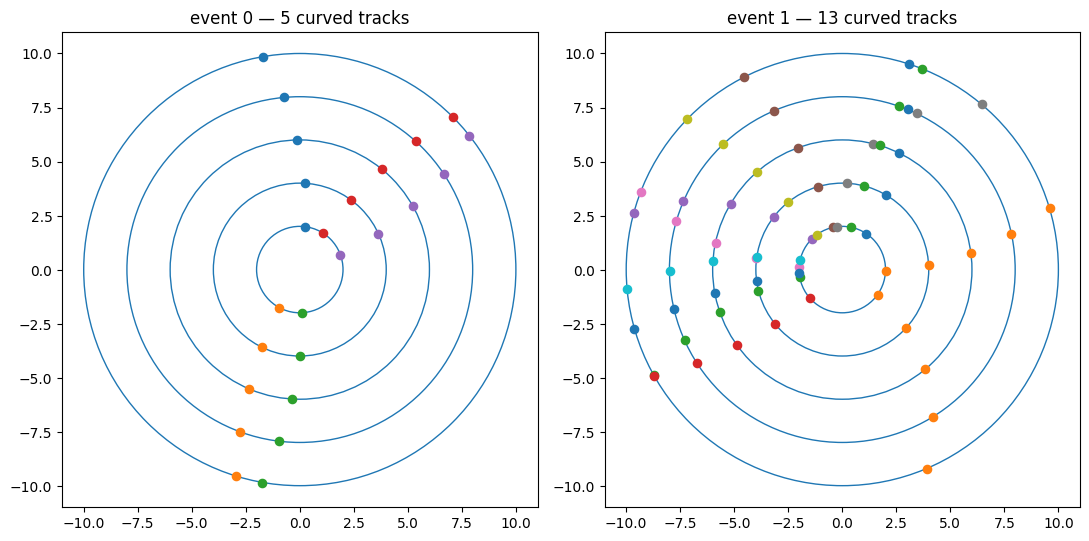

In [4]:
import matplotlib.pyplot as plt
def draw_detector(ax):
    for R in RADII: ax.add_patch(plt.Circle((0, 0), R, fill=False, color="tab:blue", lw=1))

# two example events
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, eid in zip(axes, df.event_id.unique()[:2]):
    g = df[df.event_id == eid]; draw_detector(ax)
    for tid, gg in g.groupby("track_id"):
        ax.scatter(gg.x, gg.y, s=35, color=plt.cm.tab10(tid % 10), zorder=3)
    ax.set_aspect("equal"); ax.set_xlim(-11, 11); ax.set_ylim(-11, 11)
    ax.set_title(f"event {eid} — {g.track_id.nunique()} curved tracks")
fig.tight_layout(); fig.savefig(FIG("e1_example_events.png"), dpi=150); plt.show()

R_c = pt check: corr = 0.9997, mean R_c/pt = 0.9999


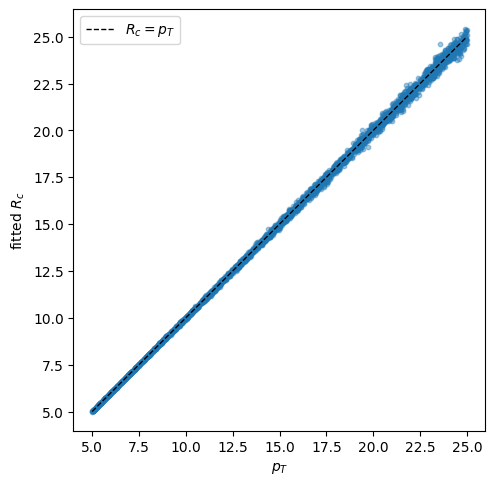

In [5]:
def fit_circle_through_origin(x, y):
    A = np.column_stack([2*x, 2*y])
    (a, b), *_ = np.linalg.lstsq(A, x**2 + y**2, rcond=None)
    return a, b, np.hypot(a, b)

if "pt" in df:
    rows = []
    for (e, t), g in df.groupby(["event_id", "track_id"]):
        if len(g) >= 3:
            _, _, Rc = fit_circle_through_origin(g.x.to_numpy(), g.y.to_numpy())
            rows.append((g.pt.iloc[0], Rc))
        if len(rows) >= 3000: break
    fit = pd.DataFrame(rows, columns=["pt", "Rc"])
    print(f"R_c = pt check: corr = {np.corrcoef(fit.pt, fit.Rc)[0,1]:.4f}, "
          f"mean R_c/pt = {(fit.Rc/fit.pt).mean():.4f}")
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(fit.pt, fit.Rc, s=10, alpha=0.4, color="tab:blue")
    lo, hi = fit.pt.min(), fit.pt.max(); ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="$R_c = p_T$")
    ax.set_xlabel("$p_T$"); ax.set_ylabel("fitted $R_c$"); ax.legend(); ax.set_aspect("equal")
    fig.tight_layout(); fig.savefig(FIG("e2_pt_vs_curvature.png"), dpi=150); plt.show()

## 3. Why the straight-line baseline breaks
In task (d) the baseline sorted hits by angle atan2(y, x), which worked because
every hit of a straight track has the same angle. A curved track sweeps through a
big range of angle across the layers, so that assumption is just wrong here. I
measure the angle span per track and run the baseline to watch it fall apart.

In [6]:
spans = []
for (e, t), g in df.groupby(["event_id", "track_id"]):
    phi = np.arctan2(g.y, g.x); spans.append((phi.max() - phi.min()) * 1e3)
print(f"per-track phi-span: median {np.median(spans):.0f} mrad (straight tracks were ~1 mrad)")

base = [hungarian_hit_accuracy(g.track_id.to_numpy(),
          baseline_phi_gap(g.x.to_numpy(), g.y.to_numpy(), g.track_id.nunique()))
        for _, g in df.groupby("event_id")]
BASE = float(np.mean(base))
print(f"straight-line baseline on curved tracks: hit accuracy = {BASE:.4f}")

per-track phi-span: median 280 mrad (straight tracks were ~1 mrad)
straight-line baseline on curved tracks: hit accuracy = 0.5822


## 4. Apply the task-(d) transformer (same method)
This is the main point of the project: the model only takes per-hit features and
predicts pairwise same-track probabilities, with no straight-line assumption
anywhere, so it applies to curved tracks with no change to the method. I split by
event (80/10/10) and train with early stopping, keeping the best validation
checkpoint. pos_weight is set to about (mean tracks - 1) to rebalance the pairwise
targets.

In [7]:
ev = df.event_id.unique(); rng = np.random.default_rng(SEED); rng.shuffle(ev)
if FAST: ev = ev[:800]
n = len(ev); n_tr, n_va = int(0.8*n), int(0.1*n)
df_tr = df[df.event_id.isin(ev[:n_tr])]
df_va = df[df.event_id.isin(ev[n_tr:n_tr+n_va])]
df_te = df[df.event_id.isin(ev[n_tr+n_va:])]
POS_W = max(df.groupby("event_id").track_id.nunique().mean() - 1, 1.0)
print(f"train {n_tr} / val {n_va} / test {n-n_tr-n_va} events; pos_weight={POS_W:.1f}")

SIZES = {"base":  dict(d_model=96,  n_heads=4, n_layers=4, d_ff=192, d_embed=48),
         "large": dict(d_model=160, n_heads=8, n_layers=6, d_ff=320, d_embed=64)}
EXTRA = ["layer"] if USE_LAYER else []
N_FEATURES = 2 + len(EXTRA); LAYER_SCALE = 4.0

train 8000 / val 1000 / test 1000 events; pos_weight=9.0


In [8]:
def make_loader(d, bs, sh=False, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    return DataLoader(EventDataset(d, extra_cols=EXTRA, extra_scale=LAYER_SCALE),
                      batch_size=bs, shuffle=sh, collate_fn=collate_events,
                      generator=g if sh else None)

def val_acc(model, vdl, max_events=150):
    model.eval(); a = []
    with torch.no_grad():
        for h, l, m in vdl:
            hd, md_ = h.to(device), m.to(device)
            p = torch.sigmoid(model.pair_logits(model(hd, md_))).cpu()
            for b in range(h.shape[0]):
                mm = m[b].numpy(); K = len(np.unique(l[b].numpy()[mm]))
                a.append(hungarian_hit_accuracy(l[b].numpy()[mm],
                         cluster_affinity(p[b].numpy()[mm][:, mm], K)))
            if len(a) >= max_events: break
    return float(np.mean(a))

def train_es(model, d_tr, d_va, max_epochs, patience=10, batch=16, lr=8e-4,
             save_path=None):
    torch.manual_seed(SEED)
    tdl = make_loader(d_tr, batch, sh=True); vdl = make_loader(d_va, 32)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)
    hist = {"loss": [], "val_acc": []}; best = -1; best_state = None; since = 0
    for ep in range(max_epochs):
        model.train(); tot = 0.0
        for h, l, m in tdl:
            h, l, m = h.to(device), l.to(device), m.to(device)
            opt.zero_grad()
            loss = pairwise_bce_loss(model.pair_logits(model(h, m)), l, m, pos_weight=POS_W)
            loss.backward(); opt.step(); tot += loss.item()
        sch.step(); va = val_acc(model, vdl); flag = ""
        hist["loss"].append(tot/len(tdl)); hist["val_acc"].append(va)
        if va > best:
            best = va; best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            since = 0; flag = " *best*"
            if save_path:
                torch.save({"state_dict": best_state,
                            "config": {**SIZES[SIZE], "n_features": N_FEATURES,
                                       "extra_cols": EXTRA, "extra_scale": LAYER_SCALE,
                                       "task": "e_curved"}}, save_path)
        else:
            since += 1
        print(f"epoch {ep:3d}  loss {hist['loss'][-1]:.4f}  val hit-acc {va:.4f}{flag}")
        if since >= patience:
            print(f"early stop (best {best:.4f})"); break
    if best_state: model.load_state_dict(best_state)
    return hist, best

model = HitSetTransformer(n_features=N_FEATURES, dropout=DROPOUT, **SIZES[SIZE]).to(device)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}  (SIZE={SIZE})")
hist, best = train_es(model, df_tr, df_va, max_epochs=10 if FAST else 40,
                      save_path=os.path.join("models", "model_e_curved.pt"))
print(f"best validation hit accuracy: {best:.4f}")

parameters: 1,276,064  (SIZE=large)
epoch   0  loss 1.0475  val hit-acc 0.6376 *best*
epoch   1  loss 0.7272  val hit-acc 0.7104 *best*
epoch   2  loss 0.6704  val hit-acc 0.7626 *best*
epoch   3  loss 0.6253  val hit-acc 0.7725 *best*
epoch   4  loss 0.6030  val hit-acc 0.7699
epoch   5  loss 0.5826  val hit-acc 0.7746 *best*
epoch   6  loss 0.5697  val hit-acc 0.7655
epoch   7  loss 0.5500  val hit-acc 0.7722
epoch   8  loss 0.5432  val hit-acc 0.7811 *best*
epoch   9  loss 0.5297  val hit-acc 0.7872 *best*
epoch  10  loss 0.5171  val hit-acc 0.7784
epoch  11  loss 0.5038  val hit-acc 0.7925 *best*
epoch  12  loss 0.4871  val hit-acc 0.7886
epoch  13  loss 0.4787  val hit-acc 0.7977 *best*
epoch  14  loss 0.4725  val hit-acc 0.7956
epoch  15  loss 0.4581  val hit-acc 0.8086 *best*
epoch  16  loss 0.4515  val hit-acc 0.8042
epoch  17  loss 0.4453  val hit-acc 0.8175 *best*
epoch  18  loss 0.4294  val hit-acc 0.8131
epoch  19  loss 0.4168  val hit-acc 0.8202 *best*
epoch  20  loss 0.40

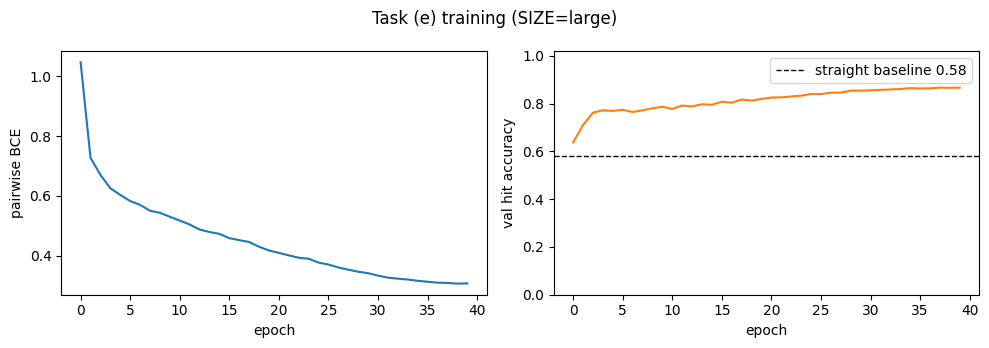

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(hist["loss"], color="tab:blue"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("pairwise BCE")
axes[1].plot(hist["val_acc"], color="tab:orange")
axes[1].axhline(BASE, color="k", ls="--", lw=1, label=f"straight baseline {BASE:.2f}")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val hit accuracy"); axes[1].set_ylim(0, 1.02); axes[1].legend()
fig.suptitle(f"Task (e) training (SIZE={SIZE})"); fig.tight_layout()
fig.savefig(FIG("e3_training.png"), dpi=150); plt.show()

## 5. Evaluation on the sealed curved test split

In [10]:
def predict_event(model, g, K):
    feats = [g.x.to_numpy()/10., g.y.to_numpy()/10.]
    if USE_LAYER: feats.append(g.layer.to_numpy()/LAYER_SCALE)
    x = torch.tensor(np.column_stack(feats), dtype=torch.float32, device=device).unsqueeze(0)
    m = torch.ones(1, x.shape[1], dtype=torch.bool, device=device)
    with torch.no_grad():
        prob = torch.sigmoid(model.pair_logits(model(x, m)))[0].cpu().numpy()
    return cluster_affinity(prob, K)

model.eval(); rows = []
for eid, g in df_te.groupby("event_id"):
    K = g.track_id.nunique(); t = g.track_id.to_numpy()
    s = event_scores(t, predict_event(model, g, K))
    sb = hungarian_hit_accuracy(t, baseline_phi_gap(g.x.to_numpy(), g.y.to_numpy(), K))
    rows.append({"event_id": eid, "nn_acc": s["hit_acc"], "nn_ari": s["ari"], "base_acc": sb})
res = pd.DataFrame(rows)
print("=== CURVED TEST RESULTS ===")
print(f"  transformer hit-acc = {res.nn_acc.mean():.4f}   ARI = {res.nn_ari.mean():.4f}")
print(f"  straight baseline   = {res.base_acc.mean():.4f}")
print(f"  NN advantage        = {res.nn_acc.mean()-res.base_acc.mean():+.4f}")

=== CURVED TEST RESULTS ===
  transformer hit-acc = 0.8717   ARI = 0.7921
  straight baseline   = 0.5779
  NN advantage        = +0.2938


## 6. Example curved events — true vs predicted

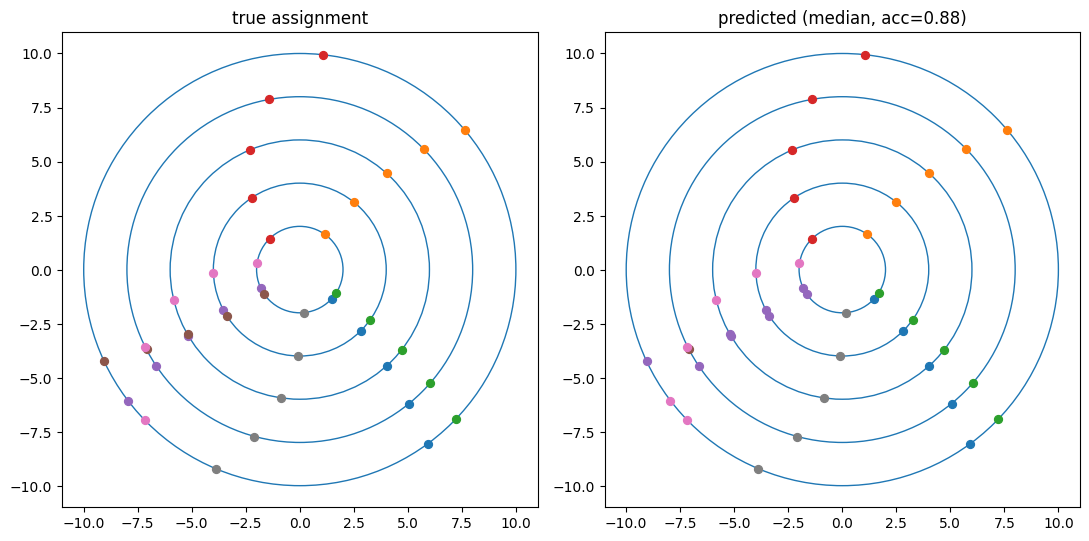

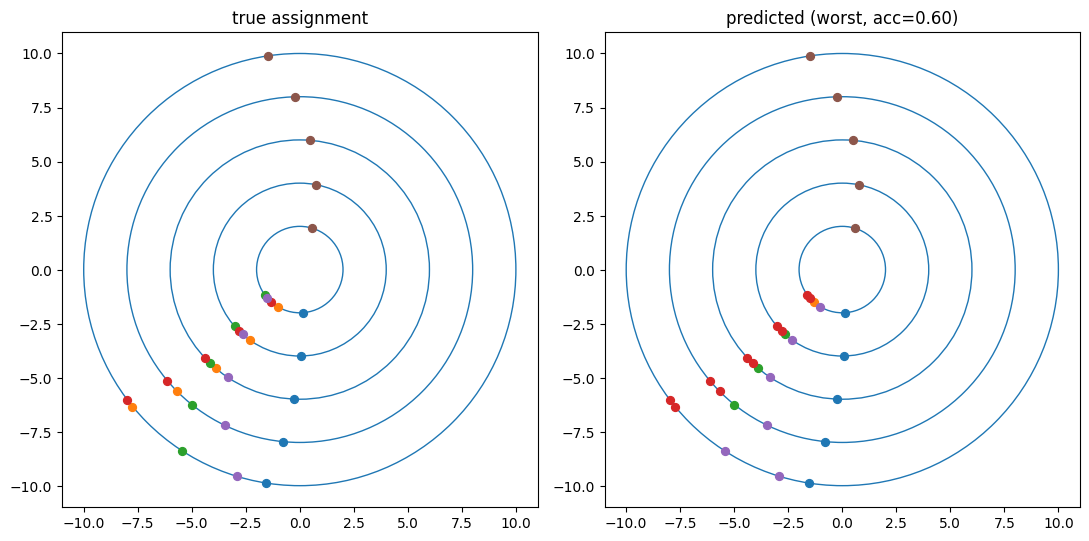

In [11]:
def matched(true, pred):
    ti, tinv = np.unique(true, return_inverse=True); pi, pinv = np.unique(pred, return_inverse=True)
    C = np.zeros((len(ti), len(pi)), int); np.add.at(C, (tinv, pinv), 1)
    r, c = linear_sum_assignment(-C); rm = {pi[cc]: ti[rr] for rr, cc in zip(r, c)}
    return np.array([rm.get(p, -1) for p in pred])

def show(g, pred, title, fname):
    fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
    for a in ax: draw_detector(a); a.set_aspect("equal"); a.set_xlim(-11, 11); a.set_ylim(-11, 11)
    for tid, gg in g.groupby("track_id"):
        ax[0].scatter(gg.x, gg.y, s=32, color=plt.cm.tab10(tid % 10), zorder=3)
    ax[0].set_title("true assignment")
    lab = matched(g.track_id.to_numpy(), pred)
    for p in np.unique(lab):
        sel = lab == p; ax[1].scatter(g.x.to_numpy()[sel], g.y.to_numpy()[sel],
                                      s=32, color=plt.cm.tab10(p % 10), zorder=3)
    ax[1].set_title(title); fig.tight_layout(); fig.savefig(FIG(fname), dpi=150); plt.show()

order = res.sort_values("nn_acc")
for tag, row in [("median", order.iloc[len(order)//2]), ("worst", order.iloc[0])]:
    g = df_te[df_te.event_id == row.event_id]
    show(g, predict_event(model, g, g.track_id.nunique()),
         f"predicted ({tag}, acc={row.nn_acc:.2f})", f"e4_event_{tag}.png")

## 7. Deliverables — predictions and fitted parameters
Predictions in the required format (event_id, x, y, trackID, ...), plus a params
file with the fitted radius of curvature for each predicted track recovered by
circle-fitting the grouped hits, so the parameters come out of the method rather
than going in.

In [12]:
ppath = os.path.join("predictions", "task_e_curved.csv")
qpath = os.path.join("predictions", "task_e_curved_params.csv")
lines, plines = [], []
for eid, g in df_te.groupby("event_id"):
    pred = matched(g.track_id.to_numpy(), predict_event(model, g, g.track_id.nunique()))
    parts = [str(eid)]
    for (x, y), p in zip(g[["x", "y"]].to_numpy(), pred):
        parts += [f"{x:.6f}", f"{y:.6f}", str(int(p))]
    lines.append(",".join(parts))
    pp = [str(eid)]
    for tid in np.unique(pred):
        sel = pred == tid
        if sel.sum() >= 3:
            _, _, Rc = fit_circle_through_origin(g.x.to_numpy()[sel], g.y.to_numpy()[sel])
        else:
            Rc = float("nan")
        pp += [str(int(tid)), f"{Rc:.4f}"]
    plines.append(",".join(pp))
open(ppath, "w").write("\n".join(lines) + "\n"); open(qpath, "w").write("\n".join(plines) + "\n")
print(f"wrote {ppath} ({len(lines)} events) and {qpath}")
print("saved models/model_e_curved.pt")

wrote predictions/task_e_curved.csv (1000 events) and predictions/task_e_curved_params.csv
saved models/model_e_curved.pt


## Summary
To recap task (e): I worked out the track model by circle-fitting, each track is
a circle through the origin with radius of curvature equal to the momentum
(confirmed by the fit), with charge setting the bend direction and the detector
unchanged. The straight-line angle baseline breaks here because a curved track
spans hundreds of mrad in angle, which kills the angle-gap trick that was
near-optimal in task (d). The same pairwise transformer, unchanged in method,
handles the varying track and hit counts and clearly beats that broken baseline 
which is exactly where a geometry-agnostic learned method earns its place, and is
the central result of the project. Track parameters are recovered afterwards by
fitting the grouped hits, never used as inputs.